In [1]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import pandas as pd
import numpy as np
from matplotlib  import pyplot as plt
import seaborn as sns

In [2]:
from car_price_prossessing_functions import *

2025-05-14 05:02:30.758315: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [4]:
#import the car sales and population size datasets
cars_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv'
population_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv'
df = load_data(cars_file_path); pop_df = load_data(population_file_path)
#process dates and define markets
df = process_dates(df)
df = define_market(df, market_vars=['sellingyear','sellingmonth','state'], market_label='market', market_code='marketid', minsize=20, dropna=False)
#value '—' for df columns color and interior is not recognized as a minus character [('—' == '-') gives False value]. So we change it manually to missing value 
df['color'] = df['color']#.replace({'—':pd.NA})
df['interior'] = df['interior']#.replace({'—':pd.NA})
#prepare replacing masks for the extract_relevant_variables function
make_mask = {
    'gmc truck':'gmc', 'dodge tk':'dodge', 'mazda tk':'mazda', 'hyundai tk':'hyundai', 'mercedes-b':'mercedes-benz',
    'chev truck':'chevrolet', 'ford tk':'ford', 'ford truck':'ford', 'vw':'volkswagen'
}
body_mask = body_type_map = {
    #suvs
    'suv': 'suv',      
    #sedans
    'sedan': 'sedan', 'g sedan': 'sedan', 'elantra coupe': 'sedan',
    #coupes
    'coupe': 'coupe', 'g coupe': 'coupe', 'genesis coupe': 'coupe', 'cts coupe': 'coupe', 'koup': 'coupe', 'cts-v coupe': 'coupe',
    'g37 coupe': 'coupe', 'q60 coupe': 'coupe',
    # convertibles
    'convertible': 'convertible', 'g convertible': 'convertible', 'g37 convertible': 'convertible', 'q60 convertible': 'convertible',
    'beetle convertible': 'convertible', 'granturismo convertible': 'convertible',
    # wagons
    'wagon': 'wagon', 'cts wagon': 'wagon', 'tsx sport wagon': 'wagon', 'cts-v wagon': 'wagon',
    # hatchbacks
    'hatchback': 'hatchback',
    # vans / minivans
    'minivan': 'van', 'van': 'van', 'e-series van': 'van', 'promaster cargo van': 'van', 'ram van': 'van', 'transit van': 'van',
    # pickup trucks - cab variants
    'crew cab': 'pickup', 'double cab': 'pickup', 'crewmax cab': 'pickup', 'access cab': 'pickup', 'king cab': 'pickup',
    'supercrew': 'pickup', 'extended cab': 'pickup', 'supercab': 'pickup', 'regular cab': 'pickup', 'regular-cab': 'pickup',
    'quad cab': 'pickup', 'club cab': 'pickup', 'xtracab': 'pickup', 'mega cab': 'pickup', 'cab plus': 'pickup', 'cab plus 4': 'pickup'
}
year_mask = dict([(str(i), str(1999)) for i in range(1980,2000)]) #To troncate all manufacturing years below 1999
color_mask = dict()
interior_mask = dict()
#prepare minimum frequencies for the extract_relevant_variables function
make_freq = 1; body_freq = 10000; year_freq = 1; color_freq = 10000; interior_freq = 10000;
#extract relevant variables
unordered_masks = dict([('year',year_mask),('make',make_mask),('body',body_mask),('color',color_mask),('interior',interior_mask)])
unordered_minfreq = dict([('year',1),('make',10000),('body',1),('color',10000),('interior',10000)])
df = extract_relevant_variables(
    df, marketvar='marketid', productvar='make', dropna=False, 
    numerical=['sellingprice','odometer','condition'], ordered=[], unordered=['year','make','body','color','interior'],
    ordered_masks=dict(), unordered_masks=unordered_masks,  ordered_min_frequencies=dict(), unordered_min_frequencies=unordered_minfreq
)

38 rows with invalid dates have been dropped

Number of missing per relevant variable in the remaining dataframe 
 marketid          485
state               0
sellingprice        0
odometer           94
condition       11794
year                0
make            10301
body            13195
color           25434
interior        17824
dtype: int64


# Le modèle structurel de la demande

Sur le marché $t$, le consommateur $i$ choisit entre les voitures de $J$ marques $1, ..., J$ et dispose également d'une option extérieure $0$ (c’est-à-dire ne pas acheter de voiture). L’utilité indirecte qui décrit les préférences du consommateur est donnée par :

$$
U_{ijt} = X_{jt}^{T}\beta_{x} + \beta_{p} P_{jt} + \xi_{jt} + \epsilon_{ijt} \equiv \delta_{jt} + \epsilon_{ijt}
$$

- $P_{jt}$ est le prix agrégé des voitures de la marque $j$  
- $X_{jt}$ contient les caractéristiques non liées au prix : kilométrage (`odometer`), état, année de fabrication (`year`), taille (`body`), couleurs intérieure (`interior`) et extérieure (`color`)  
- $\xi_{jt}$ est la qualité du produit non observée  
- $\epsilon_{ijt}$ est l’hétérogénéité non observée entre consommateurs  
- $\delta_{jt} \equiv X_{jt}^{T}\beta_{x} + \beta_{p} P_{jt} + \xi_{jt}$ est l’utilité moyenne du produit $j$  
- L’utilité moyenne de l’option extérieure est normalisée à $0$

En supposant que $\{\epsilon_{ijt}\}_{ijt}$ soient i.i.d. et suivent une loi de Gumbel, la probabilité que le consommateur $i$ achète le produit $j$ est donnée par la loi logistique multinomiale :

$$
\text{Prob}[Choix = j \mid X_{t}, P_{t}] = \frac{\exp(\delta_{jt})}{1 + \sum_{l=1}^{J} \exp(\delta_{lt})}
$$

On peut montrer que :

$$
\log\left(\text{Prob}[Choix = j \mid X_{t}, P_{t}]\right) - \log\left(\text{Prob}[Choix = 0 \mid X_{t}, P_{t}]\right) = \delta_{jt}
$$

Comme les probabilités de choix correspondent aux parts de marché $S_{jt}$ en équilibre, et puisque $\delta_{jt} \equiv X_{jt} \beta_{x} + \beta_{p} P_{jt} + \xi_{jt}$, on obtient la relation de demande suivante :

$$
\log(S_{jt}) - \log(S_{0t}) = X_{jt} \beta_{x} + \beta_{p} P_{jt} + \xi_{jt} \hspace{10mm} (1)
$$

C’est cette équation que l’on souhaite estimer. (Voir Berry, S. 1994, pour plus de détails sur ce modèle.)

---

### Prix endogène et estimation par variables instrumentales

Le prix étant endogène, il faut utiliser des méthodes basées sur des variables instrumentales $Z_{jt}$ pour identifier l’effet causal de $P_{jt}$ sur la demande (i.e. $\beta_{p}$). Une méthode de base utilisée dans ce contexte est la méthode des **doubles moindres carrés (2SLS)**, qui consiste à estimer :

1. Une spécification linéaire de la relation :

$$
P_{jt} = \mathbb{E}[P_{jt} \mid X_{t}, Z_{jt}] + \nu_{jt} \hspace{10mm} (2)
$$

Elle est linéaire si :

$$
\mathbb{E}[P_{jt} \mid X_{jt}, Z_{jt}] = X_{jt}^{T}\gamma_1 + Z_{jt}^{T}\gamma_2
$$

On note $\hat{P}_{jt}$ la prédiction du prix obtenue.

2. Puis on estime :

$$
\log(S_{jt}) - \log(S_{0t}) = X_{jt} \beta_{x} + \beta_{p} \hat{P}_{jt} + \xi_{jt} \hspace{10mm} (3)
$$

---

### Problèmes potentiels de spécification du modèle et utilité des algorithmes d’apprentissage automatique :

- Sélection des variables dans $X$ lorsque leur nombre est trop élevé par rapport à la taille de l’échantillon (ce n’est pas notre cas ici, mais on testera l’approche)
- Sélection des variables dans $X$ et $Z$ dans l'équation du prix lorsque leur nombre est élevé par rapport à la taille de l’échantillon (c’est le cas ici si on construit les instruments à partir de fonctions polynomiales d’ordre 2 des caractéristiques des produits concurrents — voir l’option `twodegree_polynomial_instruments=False` dans la fonction `aggregate_data`)
- Approximation plus flexible de $\mathbb{E}[P_{jt} \mid X_{t}, Z_{jt}]$ pour relâcher l’hypothèse de linéarité, en utilisant des mesures de performance hors échantillon


# Estimation de l'equation (3) par MCO sans remplacer $P_{jt}$ par $\hat{P}_{jt}$

Voici le probleme de moindres carres a resoudre:

$$\min_{\beta} \sum_{j,t}\left(log(S_{jt})-log(S_{0t}) - X_{jt}\beta_{x} + \beta_{p} P_{jt}\right)^{2}$$


In [265]:
#extract the final dataframe and the names of dependant, endogenous, exogenous and instruments
data,  depvars, endogvars, exogvars, instrvars = aggregate_data(
    df, pop_df, marketvar='marketid', productvar='make', twodegree_polynomial_instruments=True, 
    aggfunc='mean', numerical=['sellingprice','odometer','condition'], 
    categorical=['year','make','body','color','interior'], dep=[], 
    endog=['sellingprice'], exog=['odometer','condition','year','body','color','interior']
)
data.sellingprice = data.sellingprice/10000
data.odometer = data.odometer/10000

In [339]:
#length of endogenous, exogenous and instruments
len(endogvars), len(exogvars), len(instrvars)

count      3518.000000
mean      76376.230384
std       31700.429938
min           1.000000
25%       54696.609023
50%       72507.130903
75%       92044.388720
max      268300.750000
Name: odometer, dtype: float64

In [267]:
#dependent variables (and variables that can be used to create dependant variables)
depvars

['households (2015)',
 'allsales',
 'share_oo',
 'sales',
 'share',
 'log_share_ratio']

In [268]:
#endogenous explanatory variables
endogvars

['sellingprice']

In [269]:
data_train, data_test = train_test_split(data, test_size=0.1, random_state=42)
data_train = data_train.reset_index(drop=True); data_test = data_test.reset_index(drop=True)

In [337]:
ols_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(data_train[endogvars+exogvars])).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     14.79
Date:                Wed, 14 May 2025   Prob (F-statistic):           7.02e-86
Time:                        00:46:56   Log-Likelihood:                -6075.0
No. Observations:                3166   AIC:                         1.223e+04
Df Residuals:                    3127   BIC:                         1.246e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -11.1530      0.341  


# Selection des variables dans X par Lasso, lorsqu'on estime l'equation (3) de la demande


Voici le probleme de moindres carres regularizes par une regularisation d'elastic-net:

$$\min_{\beta} \sum_{j,t}\left(log(S_{jt})-log(S_{0t}) - X_{jt}\beta_{x} + \beta_{p} \hat{P}_{jt}\right)^{2} + \lambda \left(\alpha \sum_{k}|\beta_{k}| +  (1-\alpha)\sum_{k}\beta_{k}^{2}\right)$$

Les regularisation de Lasso ($\alpha=1$) et Ridge ($\alpha=0$) sont des cas particuliers

In [271]:
#first stage: regress price on X,Z
ols_price_model = sm.OLS(data_train[endogvars], sm.add_constant(data_train[exogvars + instrvars])).fit()
print(ols_price_model.summary())
#inside explanatory variables, replace the price by its prediction
predicted_price_train = pd.Series(ols_price_model.predict(), name=endogvars[0])
explan_data_train = pd.concat([predicted_price_train,data_train[exogvars]],axis=1)
dep_data_train = data_train[depvars[-1]]

In [272]:
##Using R package
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


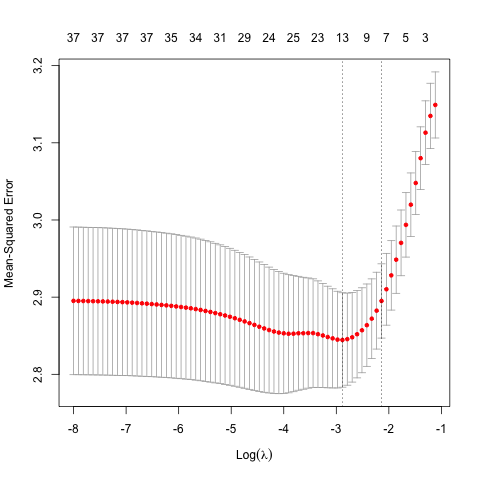

In [273]:
%%R -i explan_data_train -i dep_data_train -o coefs

library(glmnet)
set.seed(10101) #The results will change if we change this seed.
cv_fit = cv.glmnet(x=as.matrix(explan_data_train), y=dep_data_train, nfolds = 10, alpha = 1., penalty.factor = c(0,rep(1,ncol(explan_data_train)-1)))
plot(cv_fit)
lambda_chosen <- cv_fit$lambda.min
coef_matrix <- coef(cv_fit, s = lambda_chosen) #This is a sparse matrix
coefs <- as.matrix(coef_matrix) #Deparse the matrix
coefs <- as.data.frame(coefs)
colnames(coefs) <- 'Demand regression'
#help(cv.glmnet)


In [274]:
with pd.option_context('display.max_rows', 100):
    print(coefs)

                  Demand regression
(Intercept)              -11.501480
sellingprice              -0.061534
odometer                  -0.000009
condition                  0.025592
year_2013                  0.497171
year_2014                  0.121676
year_2011                  0.000000
year_2008                 -0.262436
year_2007                 -0.518403
year_2010                  0.000000
year_2006                 -0.033619
year_2009                  0.000000
year_2005                  0.000000
year_2004                  0.000000
year_2003                  0.000000
year_2015                  0.000000
year_2002                  0.000000
year_1999                  0.000000
year_2001                  0.000000
year_2000                  0.000000
body_suv                   0.000000
body_pickup                2.638144
body_van                   0.000000
body_hatchback             0.000000
body_coupe                 0.149205
body_wagon                 0.000000
body_convertible           0

In [275]:
#Final regression with selected coefs
selected_explan_vars = coefs[coefs.iloc[:,0]!=0].index[1:]
iv2sls_with_lasso_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(data_train[selected_explan_vars])).fit()
print(iv2sls_with_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     39.39
Date:                Tue, 13 May 2025   Prob (F-statistic):           2.53e-93
Time:                        23:23:13   Log-Likelihood:                -6098.3
No. Observations:                3166   AIC:                         1.222e+04
Df Residuals:                    3152   BIC:                         1.231e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -11.7975      0.262    -44.984

# Selection des variables de X, Z dans l'equation du prix (2)

In [277]:
explan_data_train = data_train[exogvars+instrvars]; explan_data_test = data_test[exogvars+instrvars]
dep_data_train = data_train[endogvars[0]]; dep_data_test = data_test[endogvars[0]]

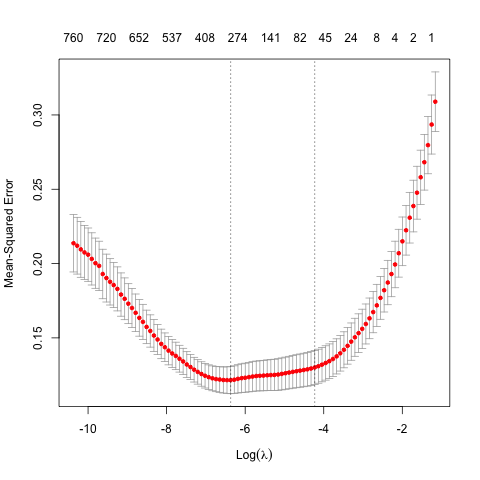

In [278]:
%%R -i explan_data_train -i explan_data_test -i dep_data_train -o coefs -o price_pred_train -o price_pred_test

library(glmnet)
set.seed(10101) #The results will change if we change this seed.
cv_fit = cv.glmnet(x=as.matrix(explan_data_train), y=dep_data_train, nfolds = 10, alpha = 1.) #, penalty.factor = c(0,rep(1,ncol(explan_data)-1)))
plot(cv_fit)
lambda_chosen <- cv_fit$lambda.min
coef_matrix <- coef(cv_fit, s = lambda_chosen) #This is a sparse matrix
coefs <- as.matrix(coef_matrix) #Deparse the matrix
coefs <- as.data.frame(coefs)
price_pred_train <- predict(cv_fit, newx = as.matrix(explan_data_train), s = lambda_chosen)
price_pred_test <- predict(cv_fit, newx = as.matrix(explan_data_test), s = lambda_chosen)


In [279]:
with pd.option_context('display.max_rows', 100):
    print(coefs)

                                                   s1
(Intercept)                                  1.682807
odometer                                    -0.000004
condition                                    0.012459
year_2013                                   -0.047668
year_2014                                    0.129632
...                                               ...
interior_beige*interior_tan_RivalProducts   -0.297666
interior_beige*interior_other_RivalProducts  0.000000
interior_tan*interior_tan_RivalProducts      0.000000
interior_tan*interior_other_RivalProducts    0.000000
interior_other*interior_other_RivalProducts  0.022626

[779 rows x 1 columns]


Text(0.5, 1.0, 'Price prediction with CV Lasso in test sample \n(r2 = 0.5617)')

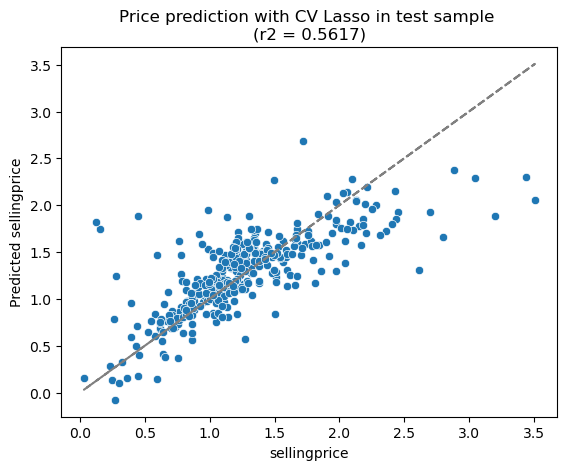

In [280]:
#Plot True vs Predicted price
r2_test = 1-(sum((dep_data_test-price_pred_test[:,0])**2)/sum((dep_data_test-np.mean(dep_data_test))**2))
sns.scatterplot(x=dep_data_test, y=price_pred_test[:,0])
plt.plot(dep_data_test, dep_data_test, linestyle='--', color='gray')
plt.xlabel("sellingprice"); plt.ylabel("Predicted sellingprice")
plt.title(f"Price prediction with CV Lasso in test sample \n(r2 = {round(r2_test,4)})")

In [281]:
#Final price regression on selected variables
selected_vars = coefs[coefs.iloc[:,0]!=0].index[1:]
ols_price_model = sm.OLS(data_train[endogvars], sm.add_constant(data_train[selected_vars])).fit()
#Apply lasso on demand regression; after replacing the price with its prediction from previous). (follows in the next cell)
predicted_price_train = pd.Series(ols_price_model.predict(sm.add_constant(data_train[selected_vars])), name=endogvars[0])
predicted_price_test = pd.Series(ols_price_model.predict(sm.add_constant(data_test[selected_vars])), name=endogvars[0])
explan_data_train = pd.concat([predicted_price_train,data_train[exogvars]],axis=1)
explan_data_test = pd.concat([predicted_price_test,data_test[exogvars]],axis=1)
dep_data_train = data_train[depvars[-1]]; dep_data_test = data_test[depvars[-1]]


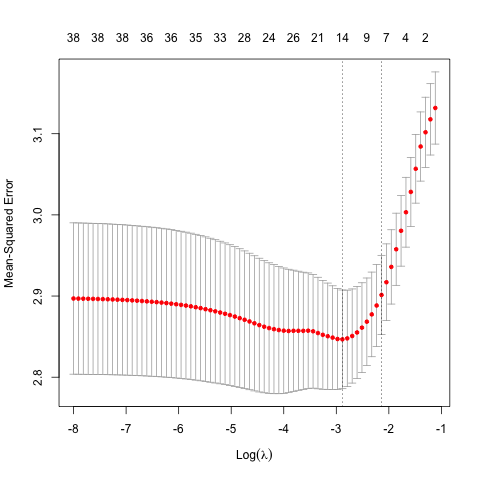

In [282]:
%%R -i explan_data_train -i explan_data_test -i dep_data_train -o coefs -o demand_pred_test

library(glmnet)
set.seed(10101) #The results will change if we change this seed.
cv_fit = cv.glmnet(x=as.matrix(explan_data_train), y=dep_data_train, nfolds = 10, alpha = 1., penalty.factor = c(0,rep(1,ncol(explan_data_train)-1)))
plot(cv_fit)
lambda_chosen <- cv_fit$lambda.min
coef_matrix <- coef(cv_fit, s = lambda_chosen) #This is a sparse matrix
coefs <- as.matrix(coef_matrix) #Deparse the matrix
coefs <- as.data.frame(coefs)
colnames(coefs) <- 'Demand regression'
demand_pred_test <- predict(cv_fit, newx = as.matrix(explan_data_test), s = lambda_chosen)


Text(0.5, 1.0, 'Mean utility prediction with CV Lasso in test sample \n(r2 = 0.0966)')

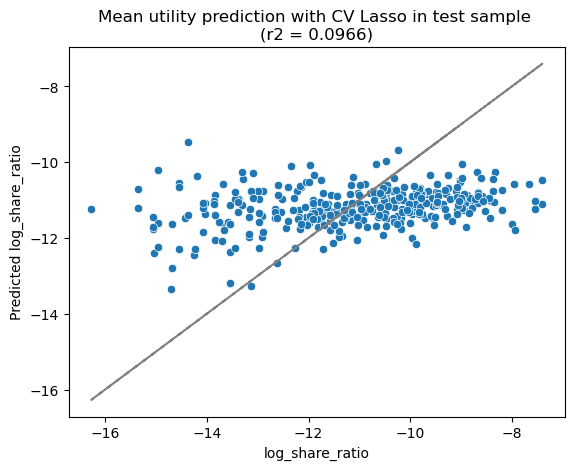

In [283]:
#Plot True vs Predicted demand
r2_test = 1-(sum((dep_data_test-demand_pred_test[:,0])**2)/sum((dep_data_test-np.mean(dep_data_test))**2))
sns.scatterplot(x=dep_data_test, y=demand_pred_test[:,0])
plt.plot(dep_data_test, dep_data_test, linestyle='--', color='gray')
plt.xlabel(depvars[-1]); plt.ylabel(f"Predicted {depvars[-1]}")
plt.title(f"Mean utility prediction with CV Lasso in test sample \n(r2 = {round(r2_test,4)})")

In [284]:
#Final demand regression with selected variables
selected_explan_vars = coefs[coefs.iloc[:,0]!=0].index[1:]
iv2sls_with_lasso_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(data_train[selected_explan_vars])).fit()
print(iv2sls_with_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     36.65
Date:                Tue, 13 May 2025   Prob (F-statistic):           9.71e-93
Time:                        23:25:49   Log-Likelihood:                -6097.7
No. Observations:                3166   AIC:                         1.223e+04
Df Residuals:                    3151   BIC:                         1.232e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -11.8279      0.264    -44.813

# Approximation flexible de $E[P_{jt}|X_{t},Z_{jt}]$ pour relacher l'hypothese de linearite

En utilisant deux methodes: forets aleatoires (random forest) et reseau de neurones profonds (deep neural network)

### Random Forests

In [287]:
X_train = data_train[exogvars+instrvars]; y_train = data_train[endogvars[0]]
X_test = data_test[exogvars+instrvars]; y_test = data_test[endogvars[0]]
# Initialize Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=5) #n_estimators = nb of trees
# Cross-validation scores (R² by default)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R² scores:", cv_scores)
print("Mean R² score:", cv_scores.mean())
# Cross-validated predictions
y_pred_train = cross_val_predict(rf, X_train, y_train, cv=5)
y_pred_test = cross_val_predict(rf, X_test, y_test, cv=5)
# Evaluation
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Cross-validated R² in training sample: {r2_train:.2f}")
print(f"Cross-validated R² in test sample: {r2_test:.2f}")

Cross-validated R² scores: [0.63984521 0.61668264 0.58517859 0.59244392 0.65170824]
Mean R² score: 0.6171717196349155
Cross-validated R² in training sample: 0.62
Cross-validated R² in test sample: 0.44


Text(0.5, 1.0, 'Price prediction with Random forests in test sample (r2 = 0.4381)')

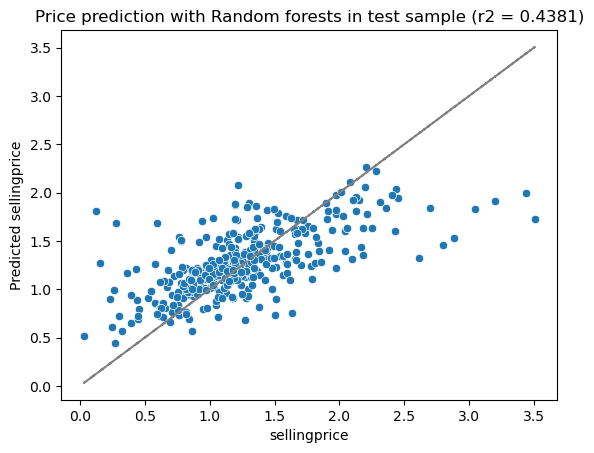

In [288]:
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot(y_test, y_test, linestyle='--', color='gray')
plt.xlabel("sellingprice"); plt.ylabel("Predicted sellingprice")
plt.title(f"Price prediction with Random forests in test sample (r2 = {round(r2_test,4)})")

### Deep Neural Network

In [290]:
X_train = data_train[exogvars+instrvars]; X_train = (X_train-X_train.mean())/X_train.std(); Y_train = data_train[endogvars[0]]
X_test = data_test[exogvars+instrvars]; X_test = (X_test-X_test.mean())/X_test.std(); Y_test = data_test[endogvars[0]]


nnmodel = keras.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(2*X_train.shape[1], activation='relu'),
    layers.Dense(2*X_train.shape[1], activation='relu'),
    layers.Dense(2*X_train.shape[1], activation='relu'),
    layers.Dense(2*X_train.shape[1], activation='relu'),
    layers.Dense(1)])
nnmodel.compile(optimizer='adam',
              loss='mae',               # Mean Squared Error for regression (is more robust to outliers)
              metrics=['mse']         # Mean Absolute Error for evaluation
             )

print(nnmodel.summary())

nnmodel.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=False)



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 1556)           │     1,212,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1556)           │     2,422,692 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1556)           │     2,422,692 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1556)           │     2,422,692 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │         1,557 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,481,757 (32.36 MB)

 Trainable params: 8,481,757 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

None


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Text(0.5, 1.0, 'Price prediction with deep neural network in test sample (r2 = 0.6377)')

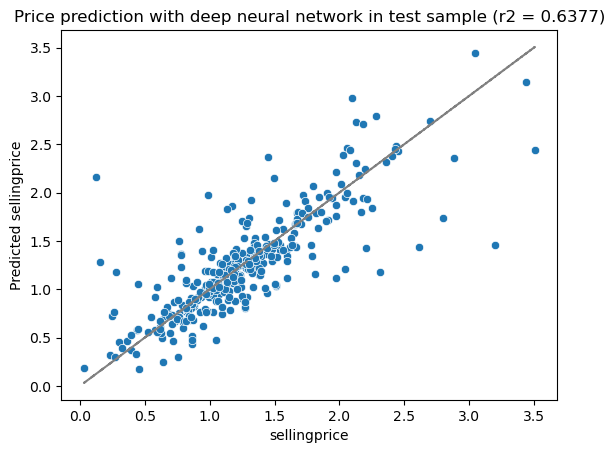

In [291]:
##Predictions from Neural Network
price_pred_train = nnmodel.predict(X_train)[:,0]
price_pred_test = nnmodel.predict(X_test)[:,0]
r2_train = 1-(sum((Y_train-price_pred_train)**2)/sum((Y_train-np.mean(Y_train))**2))
r2_test = 1-(sum((Y_test-price_pred_test)**2)/sum((Y_test-np.mean(Y_test))**2))
sns.scatterplot(x=Y_test,y=price_pred_test)
plt.plot(Y_test, Y_test, linestyle='--', color='gray')
plt.xlabel("sellingprice"); plt.ylabel("Predicted sellingprice")
plt.title(f"Price prediction with deep neural network in test sample (r2 = {round(r2_test,4)})")

### Estimate demand equation (2) using the deep neural-predicted price


In [293]:
explan_data_train = pd.concat([pd.Series(price_pred_train, name=endogvars[0]),data_train[exogvars]],axis=1)
explan_data_test = pd.concat([pd.Series(price_pred_test, name=endogvars[0]),data_test[exogvars]],axis=1)
dep_data_train = data_train[depvars[-1]]; dep_data_test = data_test[depvars[-1]]

iv2sls_with_lasso_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(explan_data_train)).fit()
print(iv2sls_with_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     14.92
Date:                Tue, 13 May 2025   Prob (F-statistic):           8.74e-87
Time:                        23:37:59   Log-Likelihood:                -6072.7
No. Observations:                3166   AIC:                         1.222e+04
Df Residuals:                    3127   BIC:                         1.246e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -11.0070      0.344  

# Introduction a la reduction de dimension: Analyse en Composantes Principales, ACP (PCA en anglais), sur les predicteurs du prix

On applique l'ACP pour reduire la dimension des predicteurs du prix. La reduction du nombre de variables pourrait nous donner plus de flexibilite pour augmenter la complexite du modele de prediction du prix.


Soit $U$ la matrice des donnees a analyser. le probleme de l'ACP consiste a trouver une matrice $P$ orthonormees telle que  $ V =  UP$ est une projection de U dans un nouvel espace qui preserve la variance (i.e. $Var[V] = Var[U]$). La matrice $V$ est appelee matrice des composantes principales.

Avantage: Les premieres $v$ colonnes de $V$ donnent une matrice qui represente $U$ dans un espace different avec la variance la plus proche de $Var[U]$ parmi les matrices de $v$ colonnes.


### Reduison  l'espace des predicteurs du prix a travers l'ACP; ensuite predisons les prix par reseaux de neuronnes profonds.

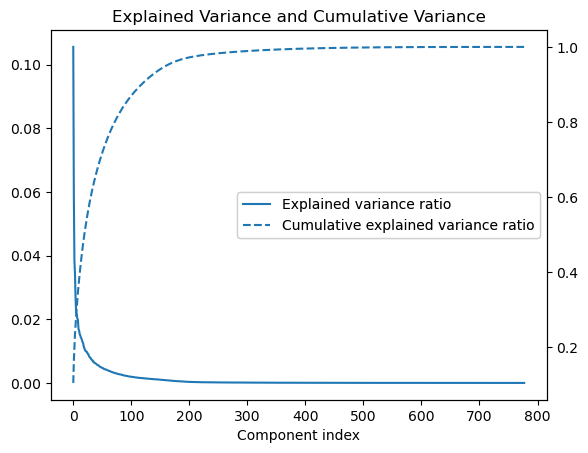

In [296]:

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(data_train[exogvars+instrvars])
X_scaled_test = scaler.fit_transform(data_test[exogvars+instrvars])

# Step 2: Apply PCA
pca = PCA(n_components=X_scaled_train.shape[1])
X_pca_train = pca.fit_transform(X_scaled_train)
X_pca_test = pca.transform(X_scaled_test)

# Step 3: View results
y=pca.explained_variance_ratio_; x=np.arange(len(pca.explained_variance_ratio_))


fig, ax = plt.subplots()
# First plot on left y-axis
line1 = sns.lineplot(x=x, y=y, ax=ax, label='Explained variance ratio')
ax.set_xlabel('Component index')
# Second plot on right y-axis
ax2 = ax.twinx()
line2 = sns.lineplot(x=x, y=y.cumsum(), linestyle='--', ax=ax2, label='Cumulative explained variance ratio')
# Combine line handles and labels
lines, labels = [], []
for axis in [ax, ax2]:
    line_objs, label_list = axis.get_legend_handles_labels()
    lines.extend(line_objs)
    labels.extend(label_list)
# Add combined legend to ax
ax.legend(lines, labels, loc='right')
ax2.legend(lines, labels, loc='right')
plt.title("Explained Variance and Cumulative Variance")
plt.show()

In [297]:
X_pca_train = pca.transform(X_scaled_train)[:,:200]; Y_train = data_train[endogvars[0]]
X_pca_test = pca.transform(X_scaled_test)[:,:200]; Y_test = data_test[endogvars[0]]


 

nnmodel = keras.Sequential([
    Input(shape=(X_pca_train.shape[1],)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1)])
nnmodel.compile(optimizer='adam',
              loss='mae',               # Mean absolute Error for regression (is more robust to outliers)
              metrics=['mse']         # Mean Squared Error for evaluation
             )

print(nnmodel.summary())

nnmodel.fit(X_pca_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=False)



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 1024)           │       205,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,554,049 (28.82 MB)

 Trainable params: 7,554,049 (28.82 MB)

 Non-trainable params: 0 (0.00 B)

None


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Text(0.5, 1.0, 'Price prediction with deep neural network in test sample (r2 = 0.635)')

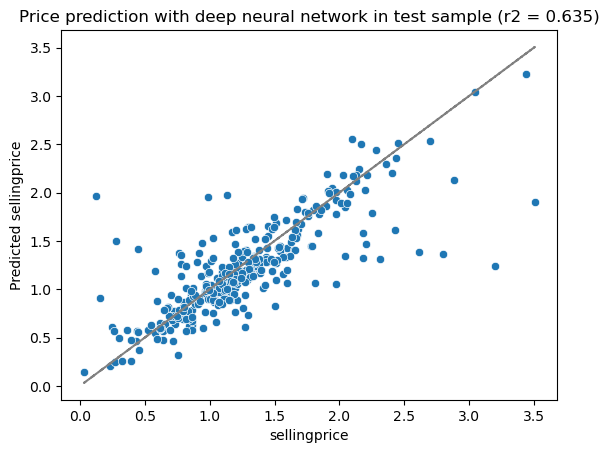

In [298]:
##Predictions from Neural Network
price_pred_train = nnmodel.predict(X_pca_train)[:,0]
price_pred_test = nnmodel.predict(X_pca_test)[:,0]
r2_train = 1-(sum((Y_train-price_pred_train)**2)/sum((Y_train-np.mean(Y_train))**2))
r2_test = 1-(sum((Y_test-price_pred_test)**2)/sum((Y_test-np.mean(Y_test))**2))
sns.scatterplot(x=Y_test,y=price_pred_test)
plt.plot(Y_test, Y_test, linestyle='--', color='gray')
plt.xlabel("sellingprice"); plt.ylabel("Predicted sellingprice")
plt.title(f"Price prediction with deep neural network in test sample (r2 = {round(r2_test,4)})")

### Estimons l'equation (3) de la demande en utilisant les prediction precedente des prix.

In [300]:
explan_data_train = pd.concat([pd.Series(price_pred_train, name=endogvars[0]),data_train[exogvars]],axis=1)
explan_data_test = pd.concat([pd.Series(price_pred_test, name=endogvars[0]),data_test[exogvars]],axis=1)
dep_data_train = data_train[depvars[-1]]; dep_data_test = data_test[depvars[-1]]

iv2sls_with_lasso_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(explan_data_train)).fit()
print(iv2sls_with_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     14.67
Date:                Tue, 13 May 2025   Prob (F-statistic):           3.86e-85
Time:                        23:42:51   Log-Likelihood:                -6076.8
No. Observations:                3166   AIC:                         1.223e+04
Df Residuals:                    3127   BIC:                         1.247e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -11.4211      0.341  

# Imputation des valeurs manquantes; en utilisant l'imputation multivariee par equations chainees (Multivariate Imputation by Chained Equations, MICE) du logiciel R

Nous allons faire un exercice d'imputation des valeurs manquantes de notre base de donnees en estimant des equations de prediction des variables ayant des valeurs manquantes. 

L'hypothese principale sur laquelle repose la procedure MICE est l'hypothese 'Missing At Random' (MAT). Autrement dit, on suppose que les valeurs manquantes surviennent de facon aleatoire dans les donnees.

Supposons une base de donnees avec trois variables A, B et C, la variable C n'ayant pas de valeurs manquantes. La procedure MICE s'applique de la facon suivante:

- iteration 0: commencer par une simple imputation univariee en ramplacant les valeurs manquantes de A et B par une statistique de tendance centrale (mode, moyenne, mediane). Mettre a jour les valeurs de A et B.
- iteration i = 1, ..., maxit:
    - regresser A sur B et C, avec les valeurs a jour de B. Predire les valeurs des donnees manquantes de A a partir de cette regression. Mettre les valeurs de A a jour.
    - regresser B sur A et C, avec les valeurs a jour de A. Predire les valeurs des donnees manquantes de B a partir de cette regression. Mettre les valeurs de B a jour.
 
Cet algorithme permet d'effectuer une imputation par equations chainees. Afin de prendre en compte l'incertitude creee par les valeurs manquantes, plusieurs imputations vont etre effectuees dans la procedure MICE. Autrement dit, plusieurs bases de donnees completees vont etre generees. Dans notre cas, nous allons retourner une seule imputation.


Les méthodes par défaut pour estimer les equations chainees sont les suivantes :

- l’appariement sur la moyenne prédictive (predictive mean matching – pmm) pour les données numériques
- l’imputation par régression logistique (logistic regression imputation – logreg) pour les données binaires
- l’imputation par régression polytomique (polytomous regression imputation – polyreg) pour les variables qualitatives à niveaux non ordonnés
- le modèle des rapports proportionnels (proportional odds model – polr) pour les variables qualitatives à niveaux ordonnés.

Nous n'allons pas utiliser ces methodes par defaut. A la place, nous allons utiliser une methode de Machine learning, en l'occurance 

In [276]:
#_, df_to_impute = train_test_split(df.drop('marketid',axis=1), test_size=20000, random_state=42)
df_to_impute = df.drop('marketid',axis=1).copy()

In [278]:
#A view of the dataframe to impute
df_to_impute

,state,sellingprice,odometer,condition,year,make,body,color,interior
0,ca,21500.0,16639.0,5.0,2015,kia,suv,white,black
1,ca,21500.0,9393.0,5.0,2015,kia,suv,white,beige
2,ca,30000.0,1331.0,45.0,2014,bmw,sedan,gray,black
3,ca,27750.0,14282.0,41.0,2015,other,sedan,white,black
4,ca,67000.0,2641.0,43.0,2014,bmw,sedan,gray,black
...,...,...,...,...,...,...,...,...,...
558832,in,33000.0,18255.0,45.0,2015,kia,sedan,silver,black
558833,wa,30800.0,54393.0,5.0,2012,other,pickup,white,black
558834,ca,34000.0,50561.0,48.0,2012,bmw,suv,black,black
558835,ga,11100.0,16658.0,38.0,2015,nissan,sedan,white,black


In [280]:
#Missing values in the dataframe to impute
df_to_impute.isna().sum(axis=0)

state               0
sellingprice        0
odometer           94
condition       11794
year                0
make            10301
body            13195
color           25434
interior        17824
dtype: int64

In [282]:
CompleteNumericalVars = ['sellingprice']; CompleteUnorderedVars = ['year']
IncompleteNumericalVars = ['odometer', 'condition']; IncompleteOrderedVars = None; IncompleteUnorderedVars = ['make','body','color','interior']
df_to_impute['saleid'] = df_to_impute.index


In [287]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [305]:

%%R -i df_to_impute  -o imputed_df

library(readr)
library(mice)
library(dplyr)
library(parallel)
library(doParallel)

CompleteNumericalVars = c('sellingprice'); CompleteUnorderedVars = c('year', 'state')
IncompleteNumericalVars = c('odometer', 'condition'); IncompleteOrderedVars = NULL; IncompleteUnorderedVars = c('make','body','color','interior')

df <- df_to_impute
#df <- select(df, -state)

if (('saleid' %in% colnames(df))==FALSE){
  df$saleid <- seq(nrow(df))
}


for (var in colnames(df)){
  if (var %in% IncompleteOrderedVars){
    df[,var] <- factor(as.integer(df[,var]), ordered=TRUE)
  }
  if (var %in% c(CompleteUnorderedVars, IncompleteUnorderedVars)){
    df[,var] <- factor(df[,var], ordered=FALSE)
  }
}


#The dataset is too heavy. For now, focus on incomlete rows, plus few additional rows (if incomplete rows are less than 100K).
incompleteness_filter <- !complete.cases(df)
complete_df <- df[!incompleteness_filter,]
nb_incomplete_rows <- sum(incompleteness_filter)
if (nb_incomplete_rows<=100000){
  sampled_rows <- sample_n(complete_df, 100000-nb_incomplete_rows)
  sampled_rows_filter <- df$saleid %in% sampled_rows$saleid
  final_filter <- incompleteness_filter | sampled_rows_filter
} else {
  final_filter <- incompleteness_filter
}

imputer <- futuremice(
  data=select(df[final_filter,], -saleid),
  blocks=list(IncompleteUnorderedVars, IncompleteNumericalVars, c(CompleteNumericalVars, CompleteUnorderedVars )), 
  method=c("rf","rf", ""), #I would've used random forests ('rf','rf','rf') if there was not computation issue
  m=10, maxit=10, #default m=5, default maxit=5
  parallelseed = 123, print = FALSE, n.core = 5
)

imputed_df <- complete(imputer)

imputed_df <- cbind(df[final_filter,'saleid'], imputed_df)
colnames(imputed_df)[1] <- 'saleid'
imputed_df <- rbind(imputed_df,df[!final_filter,])
#imputed_df <- NULL


'data.frame':	6 obs. of  9 variables:
 $ state       : Factor w/ 38 levels "ab","al","az",..: 4 4 4 4 4 4
 $ sellingprice: num  10600 4200 40000 14700 8500 34000
 $ odometer    : num  15686 8311 7983 33450 9281 ...
 $ condition   : num  44 1 49 2 1 47
 $ year        : Factor w/ 17 levels "1999","2000",..: 16 17 16 16 17 16
 $ make        : Factor w/ 17 levels "bmw","chevrolet",..: 2 8 15 2 8 1
 $ body        : Factor w/ 8 levels "convertible",..: 5 5 6 1 5 6
 $ color       : Factor w/ 9 levels "black","blue",..: 2 7 9 1 8 4
 $ interior    : Factor w/ 5 levels "beige","black",..: 2 2 2 2 3 2
       state sellingprice     odometer    condition         year         make 
           0            0           94        11794            0        10301 
        body        color     interior       saleid 
       13195        25434        17824            0 
       state sellingprice     odometer    condition         year         make 
           0            0           94        11794        

In [306]:
#There are no missing values in the imputed dataframe
imputed_df.isna().sum(axis=0)

saleid          0
state           0
sellingprice    0
odometer        0
condition       0
year            0
make            0
body            0
color           0
interior        0
dtype: int64

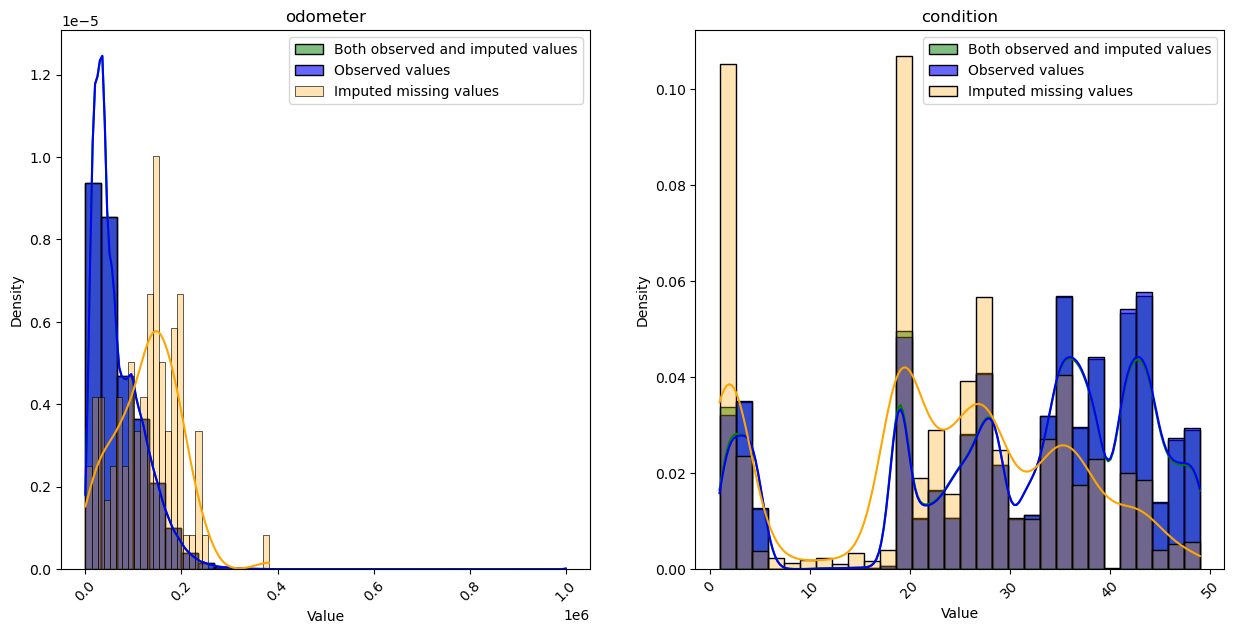

In [307]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 7))

vars = ['odometer','condition']

i = 0
for i in range(len(vars)):
    var = vars[i]
    
    incompleteness_filter = df_to_impute[var].isna()
    incompleteness_IDs = df_to_impute[incompleteness_filter]['saleid']
    observed_and_imputed_values = imputed_df[var]
    observed_values = df_to_impute[var][~incompleteness_filter]
    imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]

    ax=plt.subplot(1,2,i+1)
    sns.histplot(observed_and_imputed_values, color='green', label='Both observed and imputed values', kde=True, stat='density', bins=30)
    sns.histplot(observed_values, color='blue', label='Observed values', kde=True, stat='density', bins=30, alpha=0.6)
    sns.histplot(imputed_values, color='orange', label='Imputed missing values', kde=True, stat='density', bins=30, alpha=0.3)
    plt.xticks(rotation=45)
    plt.title(var)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
plt.show()

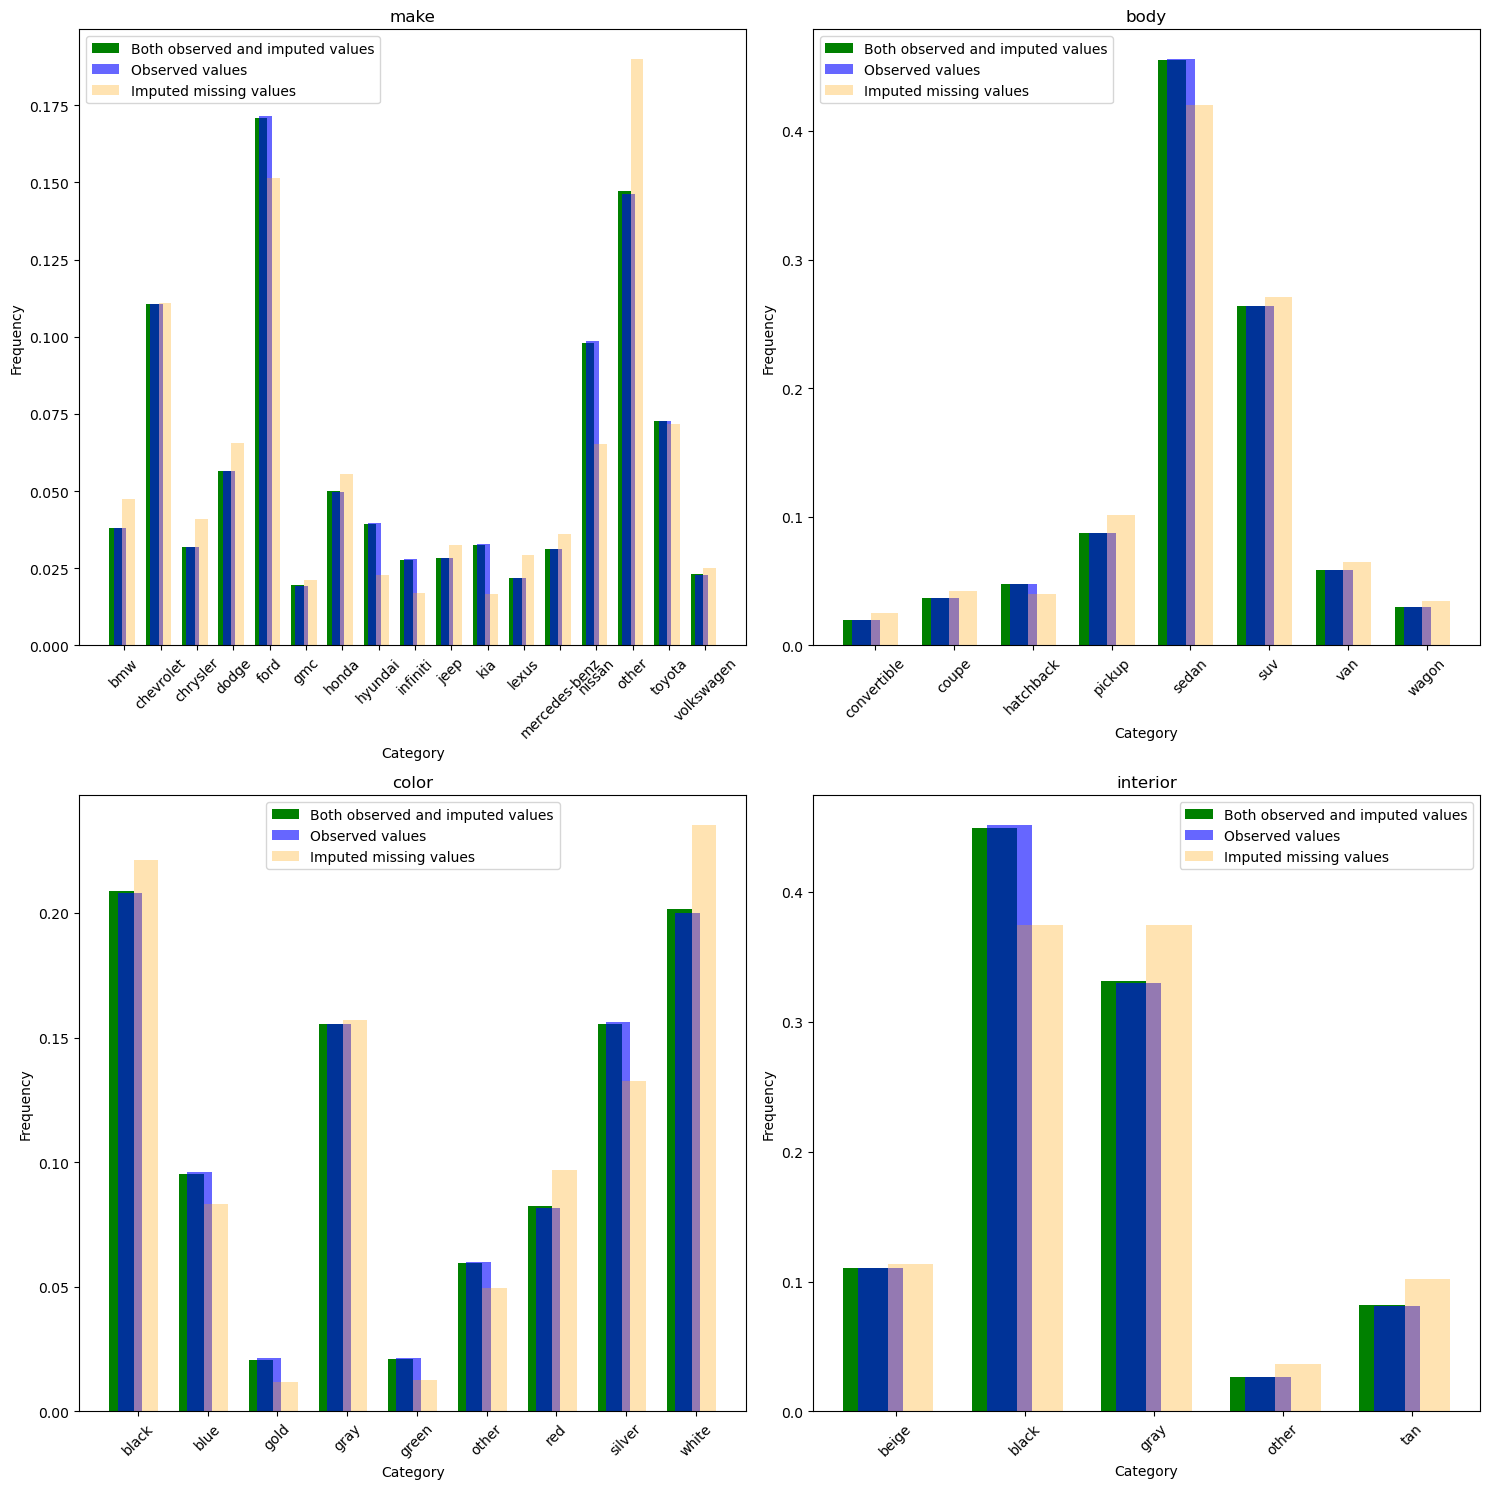

In [308]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 15))

vars = [['make','body'],['color','interior']]

i = 0
for i1 in range(2):
    for i2 in range(2):
        var = vars[i1][i2]
        incompleteness_filter = df_to_impute[var].isna()
        incompleteness_IDs = df_to_impute[incompleteness_filter]['saleid']
        observed_and_imputed_values = imputed_df[var]
        observed_values = df_to_impute[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]
        
        # Ensure same category order
        categories = sorted(set(observed_values.unique()) | set(imputed_values.unique()) | set(observed_and_imputed_values.unique()))
        
        # Compute value frequencies, reindexed to have same order
        freq_observed_and_imputed = observed_and_imputed_values.value_counts().reindex(categories, fill_value=0)/len(observed_and_imputed_values)
        freq_observed = observed_values.value_counts().reindex(categories, fill_value=0)/len(observed_values)
        freq_imputed = imputed_values.value_counts().reindex(categories, fill_value=0)/len(imputed_values)
        
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        
        i = i+1
        ax=plt.subplot(2,2,i)
        plt.bar([j - 2*width/3 for j in x], freq_observed_and_imputed, width=width, color='green', label='Both observed and imputed values')
        plt.bar([j - width/3 for j in x], freq_observed, width=width, color='blue', alpha=0.6, label='Observed values')
        plt.bar([j + width/3 for j in x], freq_imputed, width=width, color='orange', alpha=0.3, label='Imputed missing values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)

plt.show()

In [ ]:
# If we want to customize the random forest parameters inside the MICE procedure, and if we want to get the prediction performances, 
# we can define:
"""
mice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {
  require(randomForest)
  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings
  preds <- predict(rf, newdata = x[!ry, ])

  # Evaluate performance (on training set or via OOB)
  y_train <- y[ry]
  y_pred_train <- predict(rf, newdata = x[ry, ])
  mse <- mean((y_pred_train - y_train)^2)
  cat("RF training MSE:", round(mse, 3), "\n")

  return(preds)
}

then set method = "rf_custom" for the columns to be imputed using random forests.
"""

# Detection et remplacement des valeurs aberrantes par AutoEncodeur (une application du deep learning)


In [743]:
#Set the df used to check for anomalies
df_for_anomalies = imputed_df.drop('saleid',axis=1)
#Standardize numerical columns
df_numeric_mean = df_for_anomalies[['sellingprice','odometer','condition']].mean(axis=0)
df_numeric_std = df_for_anomalies[['sellingprice','odometer','condition']].std(axis=0)
df_for_anomalies[['sellingprice','odometer','condition']] = (df_for_anomalies[['sellingprice','odometer','condition']]-df_numeric_mean)/df_numeric_std
# Split the data
X_numeric = df_for_anomalies[['sellingprice','odometer','condition']]
X_state = pd.get_dummies(df_for_anomalies[['state']]); X_year = pd.get_dummies(df_for_anomalies[['year']])
X_make = pd.get_dummies(df_for_anomalies[['make']]); X_body = pd.get_dummies(df_for_anomalies[['body']])
X_color = pd.get_dummies(df_for_anomalies[['color']]); X_interior = pd.get_dummies(df_for_anomalies[['interior']])
df_for_anomalies_train, df_for_anomalies_test, X_numeric_train,  X_numeric_test, X_state_train, X_state_test, X_year_train, X_year_test,  X_make_train, X_make_test, X_body_train, X_body_test, X_color_train, X_color_test, X_interior_train, X_interior_test = train_test_split(
    df_for_anomalies, X_numeric, X_state, X_year, X_make, X_body, X_color, X_interior, test_size=0.1, random_state=42
)

X_list_train = [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train]
X_list_test = [X_numeric_test, X_state_test, X_year_test, X_make_test, X_body_test, X_color_test, X_interior_test]

X_train = pd.concat(X_list_train, axis=1)
X_test = pd.concat(X_list_test, axis=1)

#X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)
#X.head()

X_train.shape, X_test.shape

((502919, 97), (55880, 97))

In [745]:
X_numeric_train.shape,  X_numeric_test.shape, X_state_train.shape, X_state_test.shape

((502919, 3), (55880, 3), (502919, 38), (55880, 38))

In [747]:
#count levels for the categorical columns
for var in ['state','year','make','body','color','interior']:
    print(f"Column {var} has {len(imputed_df[var].unique())} levels")

Column state has 38 levels
Column year has 17 levels
Column make has 17 levels
Column body has 8 levels
Column color has 9 levels
Column interior has 5 levels


In [749]:
# Input
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(50, activation='relu')(input_layer)
encoded = Dense(20, activation='relu')(encoded)
encoded = Dense(10, activation='relu')(encoded)

# Decoder for numerical columns (e.g., 3 continuous values)
numerical_output = Dense(X_numeric_train.shape[1], activation='linear', name='numerical_output')(encoded)

# Decoder for categorical columns ('state','year','make','body','color','interior'), each with nb of dummies (38, 17, 17, 8, 9, 5)
categorical_output_state = Dense(X_state_train.shape[1], activation='softmax', name='categorical_output_state')(encoded)
categorical_output_year = Dense(X_year_train.shape[1], activation='softmax', name='categorical_output_year')(encoded)
categorical_output_make = Dense(X_make_train.shape[1], activation='softmax', name='categorical_output_make')(encoded)
categorical_output_body = Dense(X_body_train.shape[1], activation='softmax', name='categorical_output_body')(encoded)
categorical_output_color = Dense(X_color_train.shape[1], activation='softmax', name='categorical_output_color')(encoded)
categorical_output_interior = Dense(X_interior_train.shape[1], activation='softmax', name='categorical_output_interior')(encoded)

# Model with multiple outputs
autoencoder = Model(
    inputs=input_layer, 
    outputs=[numerical_output, categorical_output_state, categorical_output_year, categorical_output_make, 
             categorical_output_body, categorical_output_color, categorical_output_interior]
)

# Compile with multiple loss functions
autoencoder.compile(optimizer='adam',
                    loss={
                        'numerical_output': 'mae',
                        'categorical_output_state': 'categorical_crossentropy',
                        'categorical_output_year': 'categorical_crossentropy',
                        'categorical_output_make': 'categorical_crossentropy',
                        'categorical_output_body': 'categorical_crossentropy',
                        'categorical_output_color': 'categorical_crossentropy',
                        'categorical_output_interior': 'categorical_crossentropy',
                    },
                    loss_weights={
                        'numerical_output': 1.0,
                        'categorical_output_state': 1.0,
                        'categorical_output_year': 1.0,
                        'categorical_output_make': 1.0,
                        'categorical_output_body': 1.0,
                        'categorical_output_color': 1.0,
                        'categorical_output_interior': 1.0
                    })

autoencoder.summary()

# Fit the model
history = autoencoder.fit(
    X_train, [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train], 
    epochs=100, batch_size=1000, validation_split=0.2, verbose=False
)



Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 97)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 50)        │      4,900 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 20)        │      1,020 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 10)        │        210 │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_output    │ (None, 3)         │         33 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 38)        │        418 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 17)        │        187 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 17)        │        187 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 8)         │         88 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 9)         │         99 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_output… │ (None, 5)         │         55 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,197 (28.11 KB)

 Trainable params: 7,197 (28.11 KB)

 Non-trainable params: 0 (0.00 B)

In [750]:
X_list_train_predict =  autoencoder.predict(X_train)
X_numeric_train_predict, X_state_train_predict, X_year_train_predict, X_make_train_predict, X_body_train_predict, \
X_color_train_predict, X_interior_train_predict = X_list_train_predict

X_list_test_predict =  autoencoder.predict(X_test)
X_numeric_test_predict, X_state_test_predict, X_year_test_predict, X_make_test_predict, X_body_test_predict, \
X_color_test_predict, X_interior_test_predict = X_list_test_predict

15717/15717 ━━━━━━━━━━━━━━━━━━━━ 15s 933us/step
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1000us/step


In [757]:
## Reconstruct the input datasets
def reconstruct_columns(y_true, y_pred, numerical=True):
    #y_true should be a dataframe
    if numerical:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
    else:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
        colname = str(result.columns[0]).rpartition('_')[0]
        result = result.idxmax(axis=1).astype('string').str.rsplit('_', n=1).str[-1]
        result = pd.Series(result, name=colname)
    return result


In [825]:
df_for_anomalies_test_denoised = reconstruct_columns(y_true=X_list_test[0], y_pred=X_list_test_predict[0], numerical=True)
for i in range(1,len(X_list_train)):
    D = reconstruct_columns(y_true=X_list_test[i], y_pred=X_list_test_predict[i], numerical=False)
    df_for_anomalies_test_denoised = pd.concat([df_for_anomalies_test_denoised, D], axis=1)

    

In [871]:
def get_errors(y_true_list, y_pred_list, weight_list=[]):
    cce = CategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    if len(weight_list)==0:
        weight_list_1 = [1 for i in range(len(y_true_list))]
    else:
        weight_list_1 = weight_list
    result = weight_list_1[0]*np.mean(np.abs(y_true_list[0] - y_pred_list[0]), axis=1)
    for i in range(1,len(y_true_list)):
        result = result + weight_list_1[i]*cce(y_true_list[i],y_pred_list[i]).numpy()
    return pd.Series(result, index=y_true_list[0].index)

In [873]:
errors_train = get_errors(
    y_true_list = X_list_train, y_pred_list = X_list_train_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)
errors_test = get_errors(
    y_true_list = X_list_test, y_pred_list = X_list_test_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)

In [875]:
pd.Series(errors_train).describe(percentiles=np.arange(200)/200)

count    502919.000000
mean          0.334185
std           0.317616
min           0.016151
0%            0.016151
             ...      
98%           1.119321
98.5%         1.228187
99%           1.391473
99.5%         1.746050
max          50.272174
Length: 205, dtype: float64

In [877]:
# True data detected as anomalies
d = df_for_anomalies_test[errors_test >= 3][df_for_anomalies_test_denoised.columns]
d[['sellingprice','odometer','condition']] = (d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean
d

,sellingprice,odometer,condition,state,year,make,body,color,interior
414726,1300.0,141620.0,21.0,nm,2001,other,convertible,black,black
126002,3300.0,194582.0,27.0,az,2011,other,hatchback,black,black
528356,117500.0,12937.0,41.0,pa,2007,other,convertible,gray,other
421679,2400.0,103291.0,19.0,nm,2006,dodge,coupe,silver,gray
502115,3000.0,169531.0,19.0,nm,2000,chevrolet,pickup,red,gray
...,...,...,...,...,...,...,...,...,...
277344,27500.0,40960.0,44.0,or,2013,toyota,pickup,red,gray
513219,400.0,999999.0,19.0,oh,2006,ford,sedan,gray,gray
6724,12200.0,67240.0,4.0,ca,2010,chevrolet,pickup,white,gray
217216,12000.0,12024.0,2.0,va,2012,hyundai,hatchback,silver,black


In [881]:
# Denoised anomalies
d = df_for_anomalies_test_denoised[errors_test >= 3]#[d.columns]
d[['sellingprice','odometer','condition']] =np.round( ((d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean), 2)
d

/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_32944/930189410.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d[['sellingprice','odometer','condition']] =np.round( ((d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean), 2)


,sellingprice,odometer,condition,state,year,make,body,color,interior
414726,-644.71,164922.00,9.39,va,2001,other,convertible,black,black
126002,7423.79,132565.57,17.51,az,1999,other,hatchback,black,black
528356,35769.40,-47161.77,46.08,pa,2007,other,convertible,gray,other
421679,1375.55,121369.74,23.70,qc,2006,dodge,coupe,silver,gray
502115,-2305.38,174285.22,6.60,al,2000,chevrolet,pickup,red,gray
...,...,...,...,...,...,...,...,...,...
277344,20123.31,36922.76,19.48,hi,2013,toyota,pickup,red,gray
513219,-2528.18,202245.01,30.78,oh,2006,ford,sedan,gray,gray
6724,21966.60,457.95,28.83,ca,2010,kia,pickup,white,gray
217216,16731.86,23477.37,-1.79,on,2012,hyundai,hatchback,silver,black


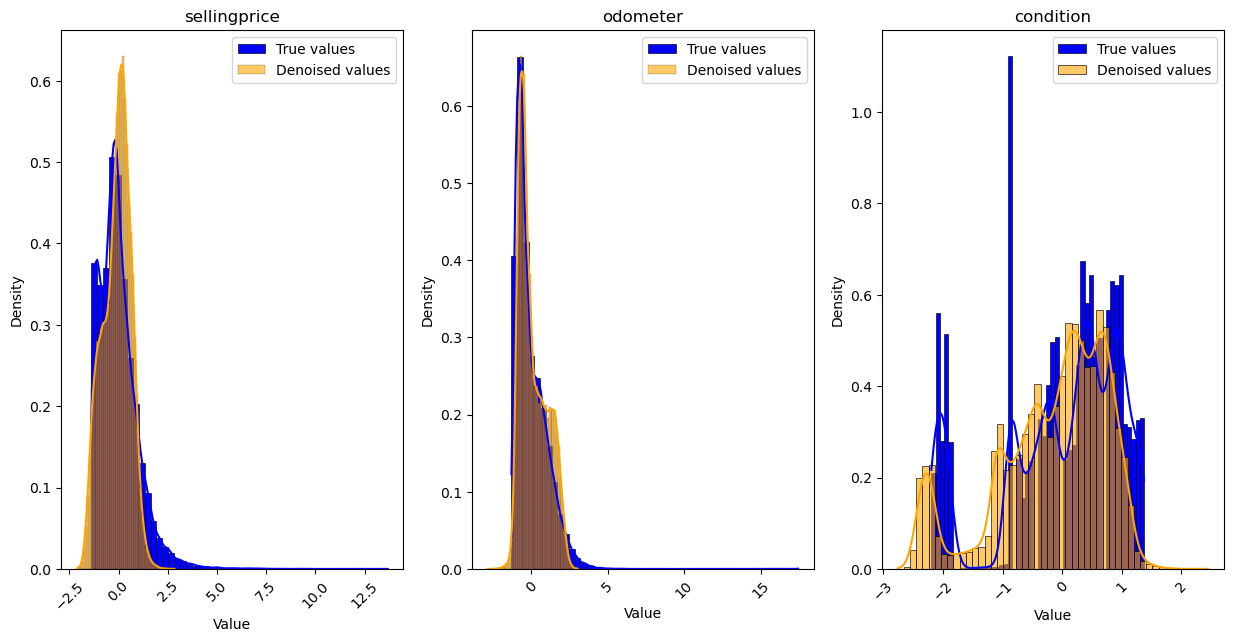

In [891]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 7))

vars = ['sellingprice','odometer','condition']

i = 0
for i in range(len(vars)):
    var = vars[i]
    ax=plt.subplot(1,3,i+1)
    sns.histplot(df_for_anomalies_test[var], color='blue', label='True values', kde=True, stat='density', bins=50, alpha=1.)
    sns.histplot(df_for_anomalies_test_denoised[var], color='orange', label='Denoised values', kde=True, stat='density', bins=50, alpha=0.6)
    plt.xticks(rotation=45)
    plt.title(var)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
plt.show()

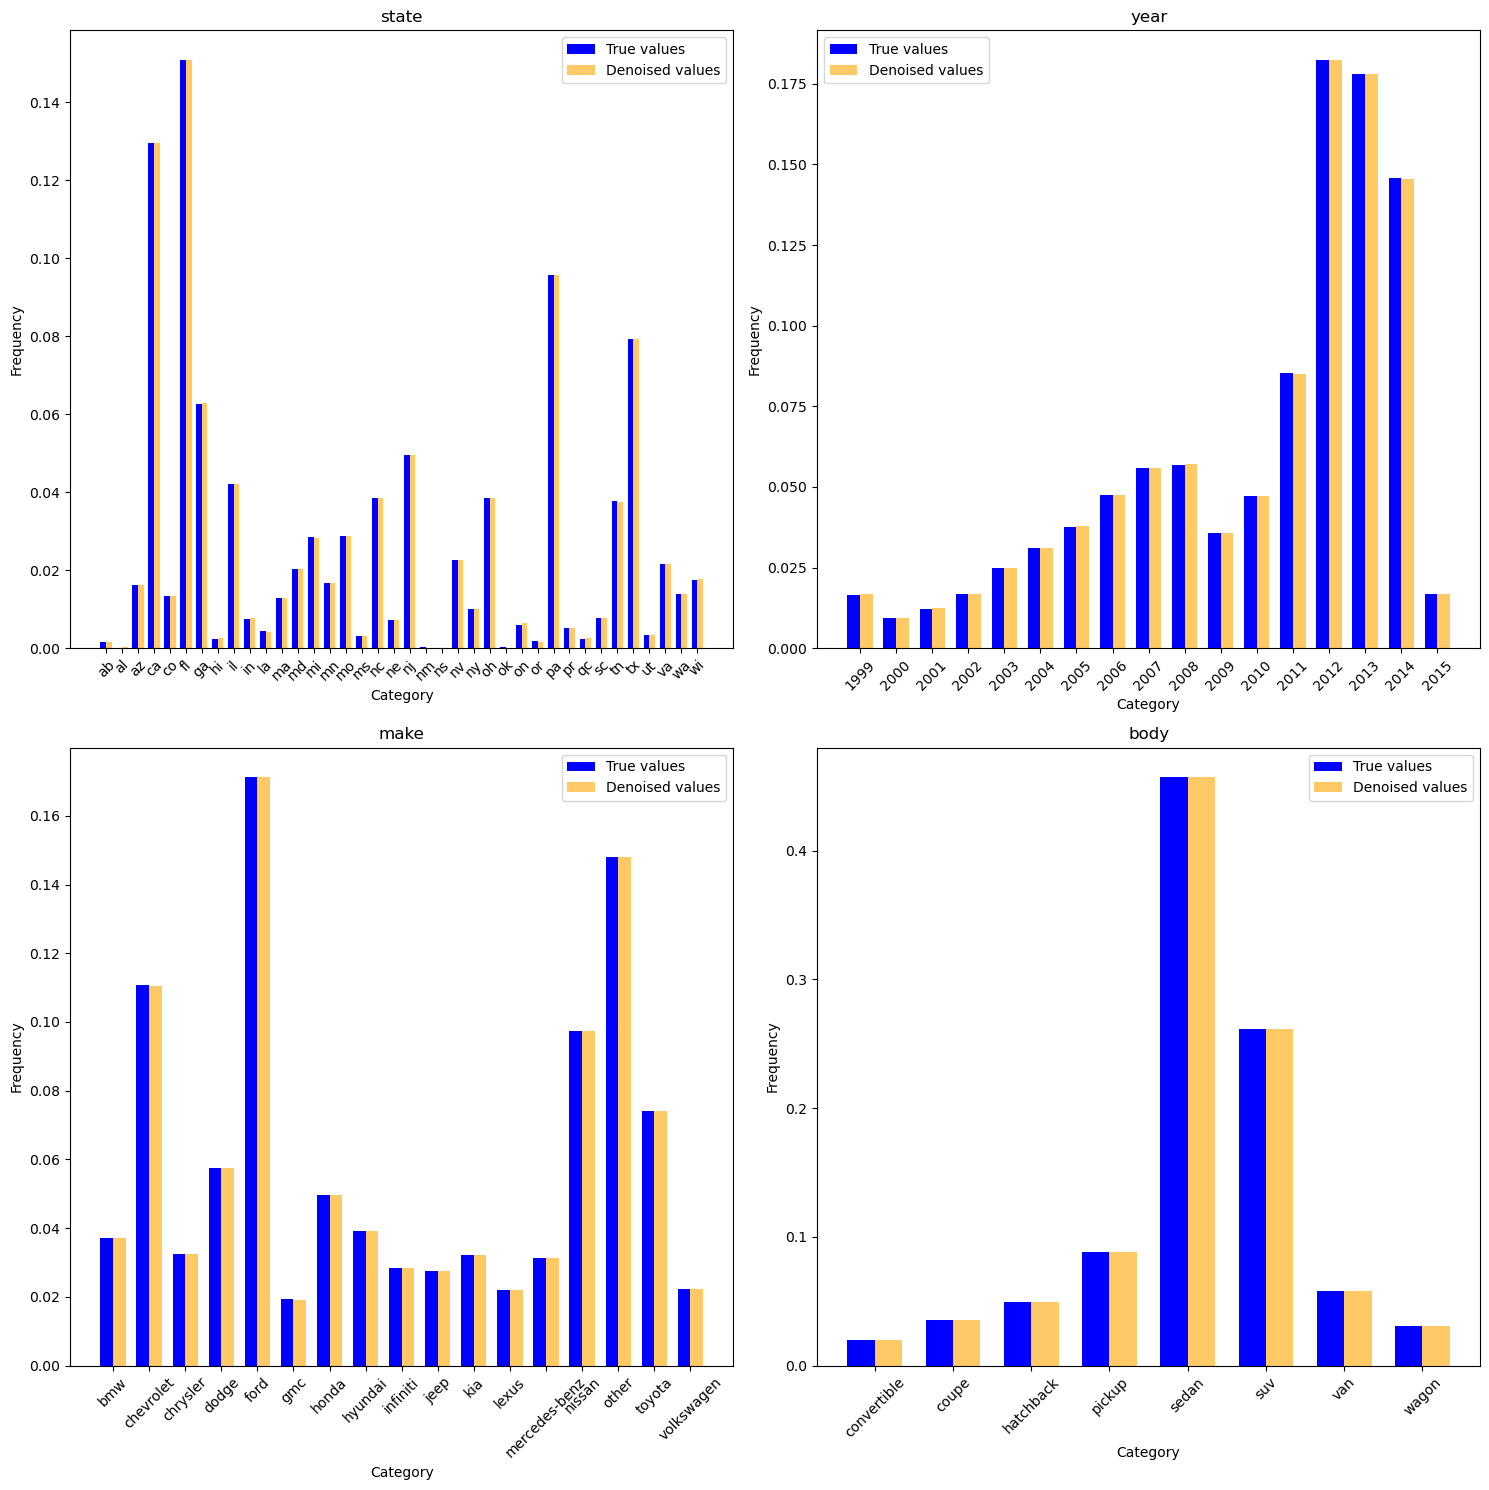

In [895]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 15))

vars = [['state','year'],['make','body'],['color','interior']]

i = 0
for i1 in range(2):
    for i2 in range(2):
        var = vars[i1][i2]
        true_values = df_for_anomalies_test[var]
        denoised_values = df_for_anomalies_test_denoised[var]
        # Ensure same category order
        categories = sorted(set(true_values.unique()) | set(denoised_values.unique()))
        # Compute value frequencies, reindexed to have same order
        freq_true = true_values.value_counts().reindex(categories, fill_value=0)/len(true_values)
        freq_denoised = denoised_values.value_counts().reindex(categories, fill_value=0)/len(denoised_values)
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        i = i+1
        ax=plt.subplot(2,2,i)
        plt.bar([j - width/2 for j in x], freq_true, width=width, color='blue', alpha=1., label='True values')
        plt.bar([j + width/2 for j in x], freq_denoised, width=width, color='orange', alpha=0.6, label='Denoised values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)

plt.show()